# Data exploration: Geneva building permits

This notebook audits the SITG building-permit export before any modelling. It establishes what the
data contains, which records can serve the eight-class task, where the data is unreliable, and how
those findings shape the partitions used by the IU project and its SwissText extension.

Every number is computed from the archived snapshot recorded in `data/raw/source_manifest.json`. The
setup cell stops if the archive no longer matches the recorded SHA-256.

In [1]:
import json
import zipfile
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import transformers
from matplotlib.ticker import StrMethodFormatter

from geneva_permits.config import ANNOTATIONS_DIR, FIGURES_DIR, load_config
from geneva_permits.prepare import PLACEHOLDERS, is_missing, normalize_description
from geneva_permits.source import (
    CSV_MEMBER,
    CSV_SEPARATOR,
    DATE_FORMAT,
    TIMESTAMP_FORMAT,
    detect_encoding,
    load_source,
    read_lock,
    verify_snapshot,
)

manifest = read_lock()
snapshot = verify_snapshot()  # stops here if the archive does not match the lock

config = load_config()
target_classes = config["data"]["target_classes"]
splits = config["data"]["splits"]

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fixed class colours in a colour-vision-deficiency-checked categorical order; slots below
# 3:1 contrast are always paired with direct labels.
CLASS_COLOURS = dict(
    zip(
        target_classes,
        ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"],
        strict=True,
    )
)
INK, MUTED, GREY = "#0b0b0b", "#52514e", "#8a8985"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titlelocation": "left",
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#e4e3df",
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "legend.frameon": False,
    }
)


def save_figure(fig, name):
    """Vector PDF for the reports, PNG for quick viewing; no timestamp, so reruns match."""
    for suffix in ("pdf", "png"):
        metadata = {"CreationDate": None} if suffix == "pdf" else None
        fig.savefig(
            FIGURES_DIR / f"{name}.{suffix}", dpi=300, bbox_inches="tight", metadata=metadata
        )

/home/dino/Dev/university/iu-bsc/nlp-project/geneva-building-permit-classification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset and prediction task

**Question:** What does the snapshot contain, and which part of it defines the classification task?

**Method:** Load the verified archive with the repository loader and record its provenance and size.

The task maps the French `DESCRIPTION` to `TYPE_OPERATION`, restricted to the eight codes in
`config.yaml`: AFF, AGR, AGV, EQU, NOU, PI, REN and VIL. AM is a genuine source category; leaving it
out defines the eight-class scope and does not make AM records invalid. Missing labels and uncertain
cases are not additional classes. CamemBERTav2-base is the selected transformer.

| Role | Fields |
|---|---|
| Model input | `DESCRIPTION` |
| Target | `TYPE_OPERATION` (eight codes) |
| Restates the target, never input | `OPERATION` |
| Record and dossier identity | `OBJECTID`, `ID_DOSSIER`, `TYPE_DOSSIER`, `NO_DOSSIER`, `NO_COMPLEMENTAIRE` |
| Time | `DATE_DEPOT` (filing), `DATE_MAJ_2` (last update) |
| Administrative context | `NOM_DOSSIER`, `STATUT`, `ORIGINE`, `LIEN_SAD` |
| Location | `E`, `N` |

Everything except the input and target supports auditing and partitioning only.

In [2]:
df = load_source()

print(
    "Downloaded:", manifest["downloaded_at"], "| Server last-modified:", manifest["last_modified"]
)
print("Rows, columns:", df.shape)
assert df["OBJECTID"].is_unique, "OBJECTID no longer identifies rows."

Downloaded: 2026-09-27T12:04:56+00:00 | Server last-modified: Sun, 27 Sep 2026 06:55:18 GMT
Rows, columns: (197224, 16)


**Finding:** The snapshot downloaded on 27 September 2026 has 197,224 rows and 16 columns. The loader
reads every field as text except the two date columns. `OBJECTID` is unique, so it is the
traceability key for every record in this notebook.

## 2. Schema and missing values

### 2.1 Placeholder values

**Question:** How does the export mark absent information?

**Method:** Count nulls and blank strings per column, list the most frequent value of every text
column and all values of the short code columns, then inspect the most frequent descriptions of at
most 15 characters, a window wide enough to contain `non renseigné` (13 characters).

In [3]:
text_columns = df.select_dtypes("string").columns
top_values = {column: df[column].value_counts().head(1) for column in text_columns}

schema = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "blank_strings": df[text_columns].apply(lambda values: values.str.strip().eq("").sum()),
        "most_frequent_value": pd.Series(
            {column: top.index[0] for column, top in top_values.items()}
        ),
        "its_count": pd.Series({column: top.iloc[0] for column, top in top_values.items()}),
    }
)
with pd.option_context("display.max_colwidth", 45):
    display(schema)

,dtype,nulls,blank_strings,most_frequent_value,its_count
DATE_DEPOT,datetime64[us],68412,NaN,NaN,NaN
DATE_MAJ_2,datetime64[us],36,NaN,NaN,NaN
DESCRIPTION,string,7,0.0,non renseigné,68411.0
E,string,0,0.0,2497036.11,92.0
ID_DOSSIER,string,0,0.0,DD 1568,3.0
LIEN_SAD,string,68411,0.0,https://app2.ge.ch/sadconsult/dossier/DD/...,3.0
N,string,0,0.0,1118989.81,92.0
NOM_DOSSIER,string,9,0.0,Demande définitive,103660.0
NO_COMPLEMENTAIRE,string,1,0.0,1,184202.0
NO_DOSSIER,string,0,0.0,93968,12.0


In [4]:
for column in ["TYPE_DOSSIER", "TYPE_OPERATION", "NO_COMPLEMENTAIRE", "STATUT", "ORIGINE"]:
    print(f"{column} ({df[column].nunique()}):", sorted(df[column].dropna().unique()))

TYPE_DOSSIER (11): ['APA', 'APAT', 'APL', 'DD', 'DP', 'DR', 'LER', 'LER-PA', 'LER-PAT', 'M', 'MPA']
TYPE_OPERATION (10): ['--', 'AFF', 'AGR', 'AGV', 'AM', 'EQU', 'NOU', 'PI', 'REN', 'VIL']
NO_COMPLEMENTAIRE (18): ['0', '1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '31', '4', '5', '6', '7', '8', '9']
STATUT (21): ['-', 'ABANDONNE', 'ACCEPTE', 'ARCHANT', 'ARCHIVE', 'AUTORISATION ANNULEE', 'CADUQUE', 'CHANTIER', 'CLOTURE ADMIN', 'DECIDE', 'EN SUSPENS', 'ENREGISTRE', 'ENREGISTREMENT', 'INSTRUCTION', 'ORMIG', 'PROCEDURE AMS', 'RECOURS', 'REFUS ENTREE', 'REFUSE', 'RENVOYE', 'TERMINE']
ORIGINE (4): ['AC-DEM', 'ANC', 'SAD', 'SIT']


In [5]:
descriptions = df["DESCRIPTION"].dropna()
short_descriptions = descriptions[descriptions.str.len() <= 15].value_counts()
shown = short_descriptions.head(20)

print("Distinct descriptions of at most 15 characters:", len(short_descriptions))
print(f"Rows covered by the 20 shown: {shown.sum():,} of {short_descriptions.sum():,}")
shown.to_frame(name="records")

Distinct descriptions of at most 15 characters: 256
Rows covered by the 20 shown: 71,293 of 71,845


,records
DESCRIPTION,
non renseigné,68411
piscine,803
véranda,727
jardin d'hiver,315
jour en toiture,137
garage,133
Piscine,115
villa - garage,113
Véranda,97


**Finding:** No column contains blank strings. Four values stand in for absent information, each in
one field:

| Field | Observed placeholder | Reading |
|---|---|---|
| `TYPE_OPERATION` | `--` | no operation code recorded |
| `OPERATION` | `Non renseigné (valeur par défaut à l'importation des données)` | "not provided (default value at data import)" |
| `DESCRIPTION` | `non renseigné` | "not provided" |
| `STATUT` | `-` | no status recorded |

The listed code values contain no other placeholder-like entry. There are 256 distinct descriptions
of at most 15 characters; the 20 most frequent, shown above, cover 71,293 of their 71,845 rows. Among
those 20, only `non renseigné` is a placeholder; the others name real objects such as `piscine`,
`véranda` or `abri de jardin`. The remaining 236 short values were not reviewed individually, so this
search covers the observed values without ruling out every other missing-value convention.

### 2.2 Nulls and placeholders per field

**Question:** How much information is missing per field once placeholders are counted?

**Method:** For each field, add true nulls and that field's own placeholder (`src.data.PLACEHOLDERS`).

In [6]:
missing_summary = (
    pd.DataFrame(
        {
            "nulls": df.isna().sum(),
            "placeholder": pd.Series(
                {column: df[column].eq(value).sum() for column, value in PLACEHOLDERS.items()}
            ),
        }
    )
    .fillna(0)
    .astype(int)
)
missing_summary["missing"] = missing_summary.sum(axis=1)
missing_summary["missing_pct"] = (100 * missing_summary["missing"] / len(df)).round(2)
missing_summary.loc[missing_summary["missing"] > 0].sort_values("missing", ascending=False)

,nulls,placeholder,missing,missing_pct
OPERATION,3,147429,147432,74.75
TYPE_OPERATION,35,147397,147432,74.75
DESCRIPTION,7,68411,68418,34.69
STATUT,7,68411,68418,34.69
DATE_DEPOT,68412,0,68412,34.69
LIEN_SAD,68411,0,68411,34.69
DATE_MAJ_2,36,0,36,0.02
NOM_DOSSIER,9,0,9,0.00
ORIGINE,3,0,3,0.00
NO_COMPLEMENTAIRE,1,0,1,0.00


**Finding:** 147,432 records (74.75%) have no operation code: 147,397 carry `--` and 35 are null.
Descriptions and statuses are each missing for 68,418 records (68,411 placeholders plus 7 nulls),
and 68,412 have no filing date. Section 2.3 tests whether these are the same records.

### 2.3 Overlap of missing fields

**Question:** Do records without a description also lack the other fields, or is missingness spread
across different records?

**Method:** Among records without a description, cross-tabulate which of four other fields are also
missing: filing date, status (null or `-`), link and operation code (null or `--`).

In [7]:
no_text = is_missing(df["DESCRIPTION"], "DESCRIPTION")
has_text = ~no_text

missing_fields = pd.DataFrame(
    {
        "filing_date": df["DATE_DEPOT"].isna(),
        "status": is_missing(df["STATUT"], "STATUT"),
        "link": df["LIEN_SAD"].isna(),
        "operation_code": is_missing(df["TYPE_OPERATION"], "TYPE_OPERATION"),
    }
)
entirely_empty = no_text & missing_fields.all(axis=1)

print(f"Records without a description: {no_text.sum():,}")
display(missing_fields[no_text].sum().to_frame(name="also_missing"))
display(
    missing_fields[no_text]
    .assign(origin_ANC=df.loc[no_text, "ORIGINE"].eq("ANC"))
    .groupby(list(missing_fields.columns))
    .agg(records=("origin_ANC", "size"), origin_ANC=("origin_ANC", "sum"))
    .sort_values("records", ascending=False)
)
print(f"Without description and all four other fields: {entirely_empty.sum():,}")
print("Described records with a missing status:", (has_text & missing_fields["status"]).sum())

Records without a description: 68,418


,also_missing
filing_date,68412.0
status,68412.0
link,68411.0
operation_code,68410.0


,,,,records,origin_ANC
filing_date,status,link,operation_code,,
True,True,True,True,68409,68406
False,False,False,False,5,0
True,True,True,False,2,2
False,False,False,True,1,0
True,True,False,False,1,0


Without description and all four other fields: 68,409
Described records with a missing status: 6


**Finding:** Of the 68,418 records without a description, 68,409 also lack a filing date, status, link
and operation code. These are entirely empty for this task, and 68,406 of them come from origin
`ANC`. The other nine lack a description but keep some fields: five have a date, status, link and
operation code. Counting nulls together with `-`, 68,412 records without a description have no
status; six described records also have a null status.

Missing descriptions and entirely empty records therefore overlap heavily but are not identical. Both
groups are outside the description-based population.

### 2.4 Administrative codes

**Question:** Which dossier types, origins and statuses occur, and are their names consistent?

**Method:** Count dossier type and name combinations, then the frequency of each origin and status,
keeping nulls visible.

In [8]:
dossier_types = (
    df.groupby(["TYPE_DOSSIER", "NOM_DOSSIER"], dropna=False)
    .size()
    .reset_index(name="records")
    .sort_values(["TYPE_DOSSIER", "records"], ascending=[True, False])
)
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(dossier_types)

for column in ["ORIGINE", "STATUT"]:
    counts = df[column].value_counts(dropna=False).to_frame(name="records")
    counts["percent"] = (100 * counts["records"] / len(df)).round(2)
    with pd.option_context("display.max_rows", None):
        display(counts)

,TYPE_DOSSIER,NOM_DOSSIER,records
1,APA,Autorisation procédure accélérée,79367
0,APA,Autorisation par procédure accélérée,5
3,APA,<NA>,3
2,APA,Procédure accélérée,1
4,APAT,Autorisation par annonce de travaux,6037
5,APL,<NA>,4
6,DD,Demande définitive,103660
7,DD,<NA>,2
8,DP,Demande préalable,1552
9,DR,Demande de renseignements,18


,records,percent
ORIGINE,,
ANC,68408,34.69
SAD,54520,27.64
SIT,53362,27.06
AC-DEM,20931,10.61
<NA>,3,0.0


,records,percent
STATUT,,
-,68411,34.69
TERMINE,62923,31.9
ARCHIVE,16943,8.59
ACCEPTE,12067,6.12
CLOTURE ADMIN,8933,4.53
RENVOYE,7954,4.03
CADUQUE,5591,2.83
ABANDONNE,4706,2.39
CHANTIER,3570,1.81


**Finding:** DD and APA account for about 92.8% of records. APA has three wording variants in
`NOM_DOSSIER`, and nine records have no dossier name (four APL, three APA, two DD).

`ORIGINE` has four codes (ANC, SAD, SIT, AC-DEM) and three nulls. Missing status covers 68,418
records (34.69%): 68,411 `-` and 7 nulls. `TERMINE` is the most frequent recorded status at 31.90%.
The export does not document APL, the origin codes, or statuses such as `ORMIG`, `ARCHANT` and
`PROCEDURE AMS`, so they stay uninterpreted.

## 3. Dates and temporal consistency

**Question:** Are the filing and update dates complete, consistently formatted and plausible?

**Method:** Re-read the raw date fields as text and count empty values, values in `YYYYMMDD`, values
in `YYYYMMDDHHMMSS` and values neither format parses. Then list the timestamp-formatted filing dates
and check for dates after the snapshot and updates earlier than filing.

In [9]:
encoding = detect_encoding(snapshot)

with zipfile.ZipFile(snapshot) as archive, archive.open(CSV_MEMBER) as csv_file:
    raw_dates = pd.read_csv(
        csv_file,
        sep=CSV_SEPARATOR,
        encoding=encoding,
        dtype="string",
        keep_default_na=False,
        usecols=["OBJECTID", "DATE_DEPOT", "DATE_MAJ_2"],
    )

date_formats = {}
for column in ["DATE_DEPOT", "DATE_MAJ_2"]:
    values = raw_dates[column].str.strip()
    as_date = pd.to_datetime(values, format=DATE_FORMAT, errors="coerce")
    as_timestamp = pd.to_datetime(values, format=TIMESTAMP_FORMAT, errors="coerce")
    date_formats[column] = {
        "empty": values.eq("").sum(),
        "YYYYMMDD": as_date.notna().sum(),
        "YYYYMMDDHHMMSS": (as_date.isna() & as_timestamp.notna()).sum(),
        "unparsed": (values.ne("") & as_date.isna() & as_timestamp.isna()).sum(),
    }
    if column == "DATE_DEPOT":
        timestamped = as_date.isna() & as_timestamp.notna()

display(pd.DataFrame(date_formats).T)

recovered_dates = (
    raw_dates.loc[timestamped, ["OBJECTID", "DATE_DEPOT"]]
    .rename(columns={"DATE_DEPOT": "raw_value"})
    .merge(
        df[["OBJECTID", "ID_DOSSIER", "ORIGINE", "TYPE_OPERATION", "DESCRIPTION", "DATE_DEPOT"]],
        on="OBJECTID",
        validate="one_to_one",
    )
    .rename(columns={"DATE_DEPOT": "analysis_date"})
)
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(recovered_dates)

assert recovered_dates["analysis_date"].notna().all()
assert not (has_text & df["DATE_DEPOT"].isna()).any(), "A described record lacks a filing date."

,empty,YYYYMMDD,YYYYMMDDHHMMSS,unparsed
DATE_DEPOT,68412,128809,3,0
DATE_MAJ_2,36,197188,0,0


,OBJECTID,raw_value,ID_DOSSIER,ORIGINE,TYPE_OPERATION,DESCRIPTION,analysis_date
0,151370,20211007105640,APAT 316218/1,SAD,--,transformation et rénovation de bureaux au 3ème étage,2021-10-07
1,154303,20220830152321,APAT 322209/1,SAD,--,installation d'un portillon,2022-08-30
2,147337,20210130170830,APAT 311661/1,SAD,--,construction d'une véranda,2021-01-30


In [10]:
snapshot_date = pd.Timestamp(manifest["downloaded_at"][:10])

print("Filing dates:", df["DATE_DEPOT"].min().date(), "to", df["DATE_DEPOT"].max().date())
print("Update dates:", df["DATE_MAJ_2"].min().date(), "to", df["DATE_MAJ_2"].max().date())
pd.Series(
    {
        "filing after snapshot": (df["DATE_DEPOT"] > snapshot_date).sum(),
        "update after snapshot": (df["DATE_MAJ_2"] > snapshot_date).sum(),
        "update before filing": (df["DATE_MAJ_2"] < df["DATE_DEPOT"]).sum(),
    },
    name="records",
).to_frame()

Filing dates: 1995-01-01 to 2026-09-25
Update dates: 1999-07-13 to 2026-09-26


,records
filing after snapshot,0
update after snapshot,0
update before filing,0


**Finding:** Three filing dates are stored as `YYYYMMDDHHMMSS`. All three are unlabelled APAT records
from SAD with descriptions, filed in 2021 and 2022. The loader keeps their date part, so the raw values
above remain the source record and `DATE_DEPOT` holds the recovered analysis dates. Every described
record now has a filing date; the 68,412 empty filing dates all belong to records without a
description. `DATE_MAJ_2` has 36 empty values and no format problems.

Filing dates run from 1995-01-01 to 2026-09-25 and updates from 1999-07-13 to 2026-09-26. No date
lies after the snapshot, and no update precedes its filing. All later temporal analysis uses the
recovered `DATE_DEPOT`; 2026 is a partial year.

## 4. Dossier identifiers and repeated records

### 4.1 Repeated dossier identifiers

**Question:** Does a repeated `ID_DOSSIER` indicate duplicated records?

**Method:** Count repeated identifiers, show three examples, count which fields vary within each
repeated identifier (a missing and a populated value count as different), and count rows identical
on all fields except `OBJECTID`, with and without coordinates.

In [11]:
dossier_counts = df["ID_DOSSIER"].value_counts()
repeated_dossiers = dossier_counts[dossier_counts > 1]

print(f"Rows: {len(df):,} | unique OBJECTID: {df['OBJECTID'].nunique():,}")
print(f"Unique ID_DOSSIER: {df['ID_DOSSIER'].nunique():,}")
print(f"Repeated identifiers: {len(repeated_dossiers)} covering {repeated_dossiers.sum()} rows")
display(
    repeated_dossiers.value_counts()
    .sort_index()
    .rename_axis("rows_per_identifier")
    .to_frame("identifiers")
)

examples = df.loc[
    df["ID_DOSSIER"].isin(repeated_dossiers.head(3).index),
    ["OBJECTID", "ID_DOSSIER", "DATE_DEPOT", "DESCRIPTION", "TYPE_OPERATION", "E", "N"],
].sort_values(["ID_DOSSIER", "OBJECTID"])
with pd.option_context("display.max_colwidth", 60, "display.max_columns", None):
    display(examples)

Rows: 197,224 | unique OBJECTID: 197,224
Unique ID_DOSSIER: 196,879
Repeated identifiers: 343 covering 688 rows


,identifiers
rows_per_identifier,
2,341
3,2


,OBJECTID,ID_DOSSIER,DATE_DEPOT,DESCRIPTION,TYPE_OPERATION,E,N
173957,176069,DD 104289/1,2011-04-19,construction de 8 abris-bus,EQU,2502339.89,1115585.62
174137,176070,DD 104289/1,2011-04-19,construction de 8 abris-bus,EQU,2502547.64,1116495.05
174138,176071,DD 104289/1,2011-04-19,construction de 8 abris-bus,EQU,2504056.67,1117466.18
43275,42308,DD 1568,NaT,non renseigné,<NA>,2498902.94,1117379.56
43276,42309,DD 1568,NaT,non renseigné,<NA>,2498924.8,1117406.63
43277,42310,DD 1568,NaT,non renseigné,<NA>,2498946.33,1117436.58
185999,176162,DD 93616/1,1996-01-01,"""HOTEL DU RHONE"" transformation des 1er,3ème,5ème et 6èm...",--,2499852.68,1117955.9
424,293,DD 93616/1,NaT,non renseigné,--,2499851,1117972.66


In [12]:
repeated_rows = df.loc[df["ID_DOSSIER"].isin(repeated_dossiers.index)]
comparison_columns = [column for column in df.columns if column not in ["OBJECTID", "ID_DOSSIER"]]
distinct_values = repeated_rows.groupby("ID_DOSSIER")[comparison_columns].nunique(dropna=False)
display(
    distinct_values.gt(1).sum().sort_values(ascending=False).to_frame(name="identifiers_differing")
)

content_columns = [column for column in df.columns if column != "OBJECTID"]
non_location_columns = [column for column in content_columns if column not in ["E", "N"]]
print("Extra identical rows, ignoring OBJECTID:", df.duplicated(subset=content_columns).sum())
print(
    "Extra matching rows, also ignoring coordinates:",
    df.duplicated(subset=non_location_columns).sum(),
)

,identifiers_differing
N,343
E,343
DATE_MAJ_2,337
DATE_DEPOT,336
STATUT,336
DESCRIPTION,336
ORIGINE,336
LIEN_SAD,335
TYPE_OPERATION,3
OPERATION,3


Extra identical rows, ignoring OBJECTID: 0


Extra matching rows, also ignoring coordinates: 8


**Finding:** All 197,224 `OBJECTID` values are unique, but there are 196,879 distinct dossier
identifiers: 341 occur twice and two three times, covering 688 rows. Every repeated identifier has
rows at different coordinates, and most also differ in dates, status, description and origin. No two
rows match on every field except `OBJECTID`; ignoring coordinates as well leaves eight matching rows.

The examples show different kinds of repetition: `DD 104289/1` has one description at three
locations, while `DD 93616/1` has one described and one empty row. A repeated identifier is therefore
not a duplicate record, and rows stay separate.

### 4.2 Conflicting codes and identifier consistency

**Question:** Do repeated identifiers carry contradictory labels, and do the identifier parts agree
with their separate columns?

**Method:** Show the repeated identifiers whose operation code, definition or dossier number differs.
Then parse `ID_DOSSIER` into type, number and optional supplementary number and compare each part
with `TYPE_DOSSIER`, `NO_DOSSIER` and `NO_COMPLEMENTAIRE`.

In [13]:
fields_to_check = ["TYPE_OPERATION", "OPERATION", "NO_DOSSIER"]
review_ids = distinct_values.index[distinct_values[fields_to_check].gt(1).any(axis=1)]

with pd.option_context("display.max_colwidth", 50, "display.max_columns", None):
    display(
        df.loc[
            df["ID_DOSSIER"].isin(review_ids),
            ["OBJECTID", "ID_DOSSIER", "NO_DOSSIER", "TYPE_OPERATION", "DESCRIPTION", "ORIGINE"],
        ].sort_values(["ID_DOSSIER", "OBJECTID"])
    )

,OBJECTID,ID_DOSSIER,NO_DOSSIER,TYPE_OPERATION,DESCRIPTION,ORIGINE
165379,165163,APA 18919/1,18919,--,installation d'un poste de régulation de gaz,SAD
6454,7137,APA 18919/1,18919,EQU,non renseigné,ANC
135320,126888,DD 105312/2,105312,EQU,<NA>,SIT
163175,165798,DD 105312/2,105312,--,(modération de trafic)modification du projet i...,SAD
1665,1710,DD 16944/1,16994,--,non renseigné,ANC
25924,26211,DD 16944/1,16944,--,non renseigné,ANC
164794,164933,DD 97325/1,97325,--,villa - véranda,SAD
2430,2431,DD 97325/1,97325,VIL,non renseigné,ANC


In [14]:
identifier_parts = (
    df["ID_DOSSIER"]
    .str.strip()
    .str.extract(
        r"^(?P<dossier_type>\S+)\s+(?P<dossier_number>\d+)(?:/(?P<supplementary_number>\d+))?$"
    )
)
identifier_checks = pd.DataFrame({"unrecognized_format": identifier_parts["dossier_number"].isna()})

for part, column in {
    "dossier_type": "TYPE_DOSSIER",
    "dossier_number": "NO_DOSSIER",
    "supplementary_number": "NO_COMPLEMENTAIRE",
}.items():
    extracted, recorded = identifier_parts[part], df[column].str.strip()
    identifier_checks[f"{part}_mismatch"] = (
        extracted.notna() & recorded.notna() & extracted.ne(recorded)
    ).fillna(False)

no_suffix = (
    identifier_parts["dossier_number"].notna() & identifier_parts["supplementary_number"].isna()
)

display(identifier_checks.sum().to_frame(name="records"))
print("Recognized identifiers without a supplementary suffix:", no_suffix.sum())
df.loc[
    identifier_checks.any(axis=1),
    ["OBJECTID", "ID_DOSSIER", "TYPE_DOSSIER", "NO_DOSSIER", "ORIGINE"],
]

,records
unrecognized_format,0.0
dossier_type_mismatch,0.0
dossier_number_mismatch,1.0
supplementary_number_mismatch,0.0


Recognized identifiers without a supplementary suffix: 30


,OBJECTID,ID_DOSSIER,TYPE_DOSSIER,NO_DOSSIER,ORIGINE
1665,1710,DD 16944/1,DD,16994,ANC


**Finding:** The three operation-code differences are missing information, not contradictions. In
`APA 18919/1`, `DD 105312/2` and `DD 97325/1`, one row has a description without a label and the
other a label without a description. Labels are not transferred between rows.

Every identifier matches the expected format, and type and supplementary number always agree with
their columns. The single inconsistency is OBJECTID `1710` in `DD 16944/1`, whose `NO_DOSSIER` is
`16994`. It is an ANC record without a description; it is flagged and not corrected, because neither
value can be shown to be right.

### 4.3 Base dossiers and supplementary applications

**Question:** How often does one base dossier contain several applications, and what key should group
them?

**Method:** Group consistent records by `(TYPE_DOSSIER, NO_DOSSIER)` and count supplementary numbers
per group; show the largest group; check identifiers without a supplementary suffix. The type is part
of the key because one number can occur under several dossier types.

In [15]:
consistent_rows = df.loc[~identifier_checks.any(axis=1)]
base_dossiers = consistent_rows.groupby(["TYPE_DOSSIER", "NO_DOSSIER"]).agg(
    records=("OBJECTID", "size"),
    supplementary_numbers=("NO_COMPLEMENTAIRE", "nunique"),
)
multiple_supplements = base_dossiers[base_dossiers["supplementary_numbers"] > 1]

print(f"Base dossiers (excluding the inconsistent record): {len(base_dossiers):,}")
print(
    f"With several supplementary numbers: {len(multiple_supplements):,} "
    f"covering {multiple_supplements['records'].sum():,} rows"
)

largest = multiple_supplements["supplementary_numbers"].idxmax()
with pd.option_context("display.max_colwidth", 110, "display.max_rows", None):
    display(
        consistent_rows.loc[
            consistent_rows["TYPE_DOSSIER"].eq(largest[0])
            & consistent_rows["NO_DOSSIER"].eq(largest[1]),
            ["OBJECTID", "ID_DOSSIER", "DATE_DEPOT", "DESCRIPTION", "TYPE_OPERATION"],
        ].sort_values("DATE_DEPOT")
    )

display(df.loc[no_suffix, "NO_COMPLEMENTAIRE"].value_counts(dropna=False).to_frame(name="records"))
print(
    "Suffix-less identifiers: origins",
    df.loc[no_suffix, "ORIGINE"].value_counts().to_dict(),
    "| with a description:",
    (no_suffix & has_text).sum(),
)

Base dossiers (excluding the inconsistent record): 183,987
With several supplementary numbers: 9,456 covering 22,442 rows


,OBJECTID,ID_DOSSIER,DATE_DEPOT,DESCRIPTION,TYPE_OPERATION
71309,70509,DD 92130/3,1996-04-18,(construction saisonnière d'un cinéma en plein air) augmentation enceintesorties de secours et déplacement...,--
97224,96235,DD 92130/4,1997-03-27,(construction saisonnière d'un cinéma en plein air) - agrandissement local WC- modification glacier- dépla...,--
97943,98230,DD 92130/6,1999-03-18,construction saisonnière d'un cinéma en plein air,--
78256,77432,DD 92130/9,2002-03-08,(construction saisonnière d'un cinéma en plein air) -réinstallation sans modification du cinéma pour la sa...,--
95159,94822,DD 92130/10,2003-03-20,(construction saisonnière d'un cinéma en plein air) - modification de la structure des gradins et de l'enc...,--
103122,103819,DD 92130/11,2004-03-03,(construction saisonnière d'un cinéma en plein air) - réinstallation du cinéma pour la saison,--
101656,102564,DD 92130/12,2005-03-18,(construction saisonnière d'un cinéma en plein air) -modification de l'enceinte côté est - adjonction d'un...,--
75264,74703,DD 92130/13,2006-03-09,(construction saisonnière d'un cinéma en plein air) - agrandissementde la terrasse (VIP) côté ouest,--
105067,105694,DD 92130/14,2007-04-05,(construction saisonnière d'un cinéma en plein air) - modification de la structure bois par du métal,--
86705,85927,DD 92130/15,2008-03-12,(construction saisonnière d'un cinéma en plein air) - reconstruction identique à la saison 2007 -,--


,records
NO_COMPLEMENTAIRE,
1,29
<NA>,1


Suffix-less identifiers: origins {'ANC': 30} | with a description: 0


**Finding:** The 183,987 base dossiers include 9,456 with several supplementary numbers, covering
22,442 rows. `DD 92130` shows the structure: twelve applications from 1996 to 2009 for a seasonal
open-air cinema. Related applications therefore share wording and context, so the partition audit
groups records by base dossier `(TYPE_DOSSIER, NO_DOSSIER)` while keeping each application as its own
record.

Thirty identifiers lack a suffix. In 29 the separate column holds `1`; for `DD 55067` (OBJECTID
`68408`) the supplementary number is missing in both places and stays unknown. All 30 are ANC records
without a description.

## 5. Labels and class balance

### 5.1 Operation codes and definitions

**Question:** Does each operation code have one definition, and how do codes relate to described
records?

**Method:** Count every combination of `TYPE_OPERATION` and `OPERATION`, with missing values kept,
and the number of described rows in each.

In [16]:
operation_definitions = (
    df.assign(has_description=has_text)
    .groupby(["TYPE_OPERATION", "OPERATION"], dropna=False)
    .agg(records=("OBJECTID", "size"), with_description=("has_description", "sum"))
    .reset_index()
    .sort_values(["TYPE_OPERATION", "records"], ascending=[True, False])
)
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(operation_definitions)

,TYPE_OPERATION,OPERATION,records,with_description
0,--,Non renseigné (valeur par défaut à l'importation des données),147397,79022
1,AFF,"Changement d'affectation important, avec ou sans rénovation",555,555
2,AGR,"Création de surfaces supplémentaires destinées à l'habitat ou aux activités (combles, surélévation, extension, ...)",2325,2324
3,AGV,"Création de surfaces supplémentaires destinées à l'habitat (combles, surélévation, extension) dans une villa",1992,1992
4,AM,"Opération d'aménagement (modification de zone, morcellement...) et de rénovation de périmètres urbains",38,38
6,EQU,"Création ou rénovation d'infrastructures, aménagement de terrains ou aménagements divers relevant du domaine public (sans construction de bâtiment)",4550,4549
5,EQU,"Création ou rénovation d' infrastructures, aménagement de terrains ou aménagements divers relevant du domaine public (sans construction de bâtiment",1,0
7,NOU,Construction nouvelle importante ou extension importante (création d'un bâtiment supplémentaire),4015,4011
8,PI,"Construction neuve de peu d'importance, isolée ou attenante au bâtiment principal, relevant du domaine privé",14815,14815
9,REN,"Travaux d'entretien et de rénovation intérieure ou extérieure, sans création de surfaces supplémentaires destinées à l'habitat ou aux activités et sans changement d'affectation important",17361,17361


**Finding:** Each code has one definition except EQU, whose second wording (an extra space, no closing
parenthesis) occurs once on a row without a description. `--` always pairs with the import-default
definition; of the 35 null codes, 32 carry that definition and three have none, and none of the 35 has
a description. Eight target-labelled rows lack a description (one AGR, two EQU, four NOU, one VIL).

AM covers planning operations such as zoning changes, subdivision and urban redevelopment. It is a
valid category outside the eight-class scope.

### 5.2 Label eligibility

**Question:** How many records can serve the description-based task, and with which label status?

**Method:** Split all rows into mutually exclusive groups using explicit membership in the eight
target classes, AM, and missing codes (null or `--`), and check that the groups add up to every row.

In [17]:
operation_code = df["TYPE_OPERATION"]
target_label = operation_code.isin(target_classes)
am_label = operation_code.eq("AM").fillna(False)
missing_label = is_missing(operation_code, "TYPE_OPERATION")
other_label = ~(target_label | am_label | missing_label)

population_counts = pd.Series(
    {
        "Without description": no_text.sum(),
        "Description and target label": (has_text & target_label).sum(),
        "Description and AM": (has_text & am_label).sum(),
        "Description, no label": (has_text & missing_label).sum(),
        "Description, unexpected code": (has_text & other_label).sum(),
    },
    name="records",
)
assert population_counts.sum() == len(df), "Population counts do not reconcile."
population_counts.to_frame()

,records
Without description,68418
Description and target label,49746
Description and AM,38
"Description, no label",79022
"Description, unexpected code",0


**Finding:** 128,806 records have a usable description: 49,746 with a target label, 79,022 without a
label and 38 with AM. No unexpected code occurs. The remaining 68,418 records have no description.
The 79,022 unlabelled descriptions are annotation candidates; a description alone does not show that
a record fits the eight-class taxonomy.

### 5.3 Class balance

**Question:** How evenly are the eight classes represented among usable labelled descriptions?

**Method:** Count target labels among the 49,746 described, target-labelled records across all years,
before any partition exclusion.

,records,percent
TYPE_OPERATION,,
AFF,555,1.1
AGR,2324,4.7
AGV,1992,4.0
EQU,4549,9.1
NOU,4011,8.1
PI,14815,29.8
REN,17361,34.9
VIL,4139,8.3


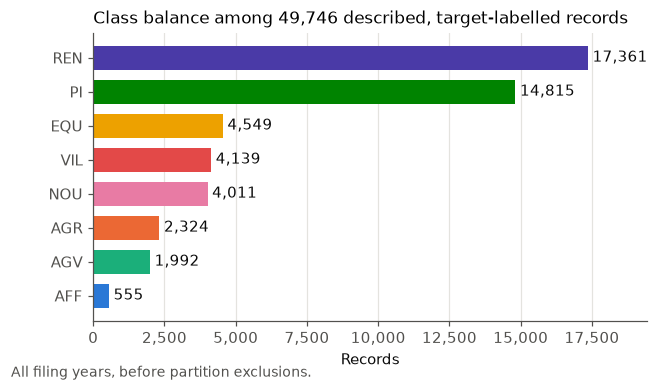

In [18]:
class_counts = (
    df.loc[has_text & target_label, "TYPE_OPERATION"].value_counts().reindex(target_classes)
)
class_share = (100 * class_counts / class_counts.sum()).round(1)
display(pd.DataFrame({"records": class_counts, "percent": class_share}))

ordered = class_counts.sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
bars = ax.barh(ordered.index, ordered, height=0.7, color=[CLASS_COLOURS[c] for c in ordered.index])
ax.bar_label(bars, labels=[f"{value:,}" for value in ordered], padding=3, color=INK)
ax.set_xlim(0, ordered.max() * 1.12)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Records")
ax.set_title(f"Class balance among {class_counts.sum():,} described, target-labelled records")
fig.text(0.01, -0.04, "All filing years, before partition exclusions.", color=MUTED, fontsize=9)
save_figure(fig, "class_balance")
plt.show()

**Finding:** REN (17,361; 34.9%) and PI (14,815; 29.8%) together make up 64.7% of the 49,746 labelled
descriptions. AFF has 555 records (1.1%), about 31 times fewer than REN, and the other five classes
hold 4.0–9.1% each. A model can reach high accuracy by favouring REN and PI while failing the small
classes, which is why macro-F1 is the primary metric. The figure describes all usable labelled
records; the partitions in Section 11 have different class mixes.

## 6. Description quality and length

### 6.1 Length

**Question:** How long are descriptions, and does length differ by label group?

**Method:** Measure characters and whitespace-separated words for every usable description, then
compare character lengths across the eight classes, AM and unlabelled records.

In [19]:
text_audit = df.loc[has_text, ["OBJECTID", "ID_DOSSIER", "DESCRIPTION", "TYPE_OPERATION"]].copy()
text_audit["label_group"] = (
    text_audit["TYPE_OPERATION"].fillna("Unlabelled").replace({"--": "Unlabelled"})
)
text_audit["characters"] = text_audit["DESCRIPTION"].str.len()
text_audit["words"] = text_audit["DESCRIPTION"].str.split().str.len()

percentiles = [0.5, 0.9, 0.95, 0.99]
display(text_audit[["characters", "words"]].describe(percentiles=percentiles).round(1))
display(text_audit.groupby("label_group")["characters"].describe(percentiles=percentiles).round(1))

print("Descriptions with exactly 254 characters:", text_audit["characters"].eq(254).sum())
print("Descriptions longer than 254 characters:", text_audit["characters"].gt(254).sum())

,characters,words
count,128806.0,128806.0
mean,64.5,8.9
std,44.2,6.3
min,3.0,1.0
50%,51.0,7.0
90%,123.0,17.0
95%,160.0,22.0
99%,236.0,33.0
max,254.0,46.0


,count,mean,std,min,50%,90%,95%,99%,max
label_group,,,,,,,,,
AFF,555.0,69.0,30.7,19.0,65.0,100.2,123.6,191.1,254.0
AGR,2324.0,73.4,42.9,7.0,62.0,130.0,157.8,227.0,254.0
AGV,1992.0,64.4,40.3,5.0,54.0,118.0,142.4,209.4,254.0
AM,38.0,47.3,22.9,17.0,43.0,82.5,90.6,103.2,105.0
EQU,4549.0,55.9,34.0,7.0,46.0,98.0,121.0,184.5,254.0
NOU,4011.0,90.1,53.4,5.0,77.0,166.0,201.0,254.0,254.0
PI,14815.0,40.6,26.5,3.0,37.0,73.0,89.0,131.0,254.0
REN,17361.0,57.3,30.6,6.0,49.0,96.0,117.0,170.0,254.0
Unlabelled,79022.0,68.2,46.8,3.0,53.0,133.0,172.0,253.8,254.0


Descriptions with exactly 254 characters: 917
Descriptions longer than 254 characters: 0


**Finding:** The 128,806 descriptions have a median of 51 characters and seven words; 99% have at
most 236 characters. Length differs by class: the median is 37 characters for PI against 77 for NOU
and 83 for VIL. No description exceeds 254 characters, while 917 have exactly 254.

### 6.2 Short descriptions and the 254-character boundary

**Question:** Do the shortest descriptions carry enough information, and are boundary-length
descriptions cut off?

**Method:** Show the two shortest distinct descriptions per label group. Then show a reproducible
sample of eight distinct descriptions with exactly 254 characters and read their endings.

In [20]:
short_examples = (
    text_audit.sort_values(["characters", "OBJECTID"])
    .drop_duplicates(["label_group", "DESCRIPTION"])
    .groupby("label_group", sort=False)
    .head(2)
    .sort_values(["label_group", "characters"])
)
with pd.option_context("display.max_rows", None):
    display(short_examples[["OBJECTID", "label_group", "characters", "DESCRIPTION"]])

at_limit = text_audit.loc[text_audit["characters"].eq(254)].drop_duplicates("DESCRIPTION")
print("Distinct descriptions with exactly 254 characters:", len(at_limit))
limit_examples = at_limit.sample(n=8, random_state=42)
with pd.option_context("display.max_colwidth", None):
    display(
        limit_examples[["OBJECTID", "label_group"]].assign(
            last_40=limit_examples["DESCRIPTION"].str[-40:]
        )
    )

,OBJECTID,label_group,characters,DESCRIPTION
87109,85851,AFF,19,création de bureaux
102709,102261,AFF,22,aménagement de bureaux
108666,107310,AGR,7,véranda
98204,97391,AGR,9,couvert -
92497,91651,AGV,5,villa
106271,106901,AGV,7,véranda
188049,178021,AM,17,dragage d'un port
185791,176140,AM,18,réaménagement rues
115885,116621,EQU,7,véranda
114237,113277,EQU,8,trottoir


Distinct descriptions with exactly 254 characters: 898


,OBJECTID,label_group,last_40
154542,155721,Unlabelled,rice de chaleur alimentée en combustible
186157,178668,Unlabelled,tection et d'entretien important des cou
152978,155239,Unlabelled,"combustibles fossiles , Installation de"
195524,196673,Unlabelled,extérieurs) - travaux de mise en confor
87670,88162,Unlabelled,othermiques - - aménagements extérieur
153540,157971,Unlabelled,age et création de faux-plafond coupe-fe
166133,167674,Unlabelled,"gements extérieurs, terrasses et escalie"
155967,146649,Unlabelled,réglementation de la circulation) - aba


**Finding:** The shortest descriptions name an object without the operation: `véranda` appears under
AGR, AGV and EQU, and `villa` under AGV, NOU and VIL. This is ambiguity in the text; it does not show
which recorded labels, if any, are wrong.

The 917 boundary rows hold 898 distinct descriptions. A hard ceiling with a concentration exactly at
it is consistent with a 254-character source field limit. Several sampled endings stop mid-word
(`confor`, `coupe-fe`, `escalie`) and are visibly cut off; others end at a word or list boundary, so
not every boundary-length description is demonstrably truncated. All eight sampled descriptions are
unlabelled, so the sample says nothing about labelled boundary records. Short and boundary-length
descriptions are kept.

### 6.3 Encoding

**Question:** Do descriptions show signs of a decoding error?

**Method:** Search for the Unicode replacement character, control characters, and byte sequences
typical of UTF-8 text decoded as Latin-1 (`Ã`, `Â`, `â€`, `ðŸ`), then read every match. A pattern
match is a heuristic flag, not a confirmed error.

In [21]:
print("Encoding detected for the CSV:", encoding)

encoding_patterns = {
    "replacement_character": "�",
    "possible_mojibake": r"Ã|Â|â€|ðŸ",
    "control_character": r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]",
}
encoding_flags = pd.DataFrame(
    {
        name: text_audit["DESCRIPTION"].str.contains(pattern, regex=True, na=False)
        for name, pattern in encoding_patterns.items()
    }
)
display(encoding_flags.sum().to_frame(name="flagged_rows"))
with pd.option_context("display.max_colwidth", None):
    display(text_audit.loc[encoding_flags.any(axis=1), ["OBJECTID", "DESCRIPTION"]])

Encoding detected for the CSV: utf-8-sig


,flagged_rows
replacement_character,0
possible_mojibake,11
control_character,0


,OBJECTID,DESCRIPTION
69136,70117,"""GRAND THEÂTRE DE GENEVE""transformation d'un sanitaire au 4ème étage"
71826,72423,"""GRAND THEÂTRE DE GENEVE""Déplacement d'une porte de WC et créationd'un mur de séparation dans un bureau au 4ème étage"
73149,74351,"""GRAND THEÂTRE DE GENEVE""transformation d'un groupe sanitaire au 1er sous-sol"
97358,98093,"""GRAND THEÂTRE DE GENEVE""transformation intérieure de bureaux -"
108832,109854,"""CASINO-THEÂTRE""transformation du local décors"
122173,121298,"changement d'affectation d'équipement collectif en habitat collectif ""BÂTIMENT C653"""
122353,121338,"changement d'affectation d'équipement collectif en habitat collectif ""BÂTIMENT C116"""
164555,164171,"""BÂTIMENT C653""changement d'affectation d'équipement collectif en habitat collectifprovisoire jusqu'au 31.12.2016"
182979,185677,réaménagement des locaux pour activités médicaux-soignantes - BÂTIMENT LES PLATANES
186111,177903,"""VILLAGE AIGUES-VERTES""transformation et agrandissement du bâtiment ""PÂQUERETTE"""


**Finding:** The CSV decodes as `utf-8-sig`. No description contains a replacement or control
character. The 11 heuristic matches all contain `Â` inside readable capitalised words such as
`THEÂTRE` or `BÂTIMENT`, which is a correctly decoded accented capital rather than mojibake. They are
11 flags, not 11 confirmed encoding errors, and no encoding correction is applied.

## 7. Repeated text and label disagreement

### 7.1 Exact repetition

**Question:** How often is the same description reused, and do identical descriptions carry
different labels?

**Method:** Group the original text unchanged, counting rows and distinct dossier identifiers per
text. Among target-labelled rows, find texts with more than one class and summarise the label mix of
the 15 texts affecting the most rows.

In [22]:
exact_texts = (
    text_audit.groupby("DESCRIPTION")
    .agg(records=("OBJECTID", "size"), dossier_identifiers=("ID_DOSSIER", "nunique"))
    .sort_values("records", ascending=False)
)
repeated_texts = exact_texts[exact_texts["records"] > 1]
print(f"Distinct descriptions: {len(exact_texts):,} of {len(text_audit):,} rows")
print(
    f"Repeated descriptions: {len(repeated_texts):,}",
    f"covering {repeated_texts['records'].sum():,} rows",
)
display(repeated_texts.head(5))

target_texts = text_audit.loc[text_audit["TYPE_OPERATION"].isin(target_classes)]
labels_per_text = target_texts.groupby("DESCRIPTION")["TYPE_OPERATION"].nunique()
conflicting_rows = target_texts.loc[
    target_texts["DESCRIPTION"].isin(labels_per_text.index[labels_per_text > 1])
]

conflict_counts = pd.crosstab(
    conflicting_rows["DESCRIPTION"], conflicting_rows["TYPE_OPERATION"]
).reindex(columns=target_classes, fill_value=0)
conflict_summary = conflict_counts.assign(
    labelled_rows=conflict_counts.sum(axis=1),
    largest_label_pct=(100 * conflict_counts.max(axis=1) / conflict_counts.sum(axis=1)).round(1),
)
print(
    f"Texts with several target labels: {len(conflict_counts):,} | rows: {len(conflicting_rows):,} "
    f"| dossier identifiers: {conflicting_rows['ID_DOSSIER'].nunique():,}"
)
with pd.option_context("display.max_colwidth", 55, "display.max_columns", None):
    display(conflict_summary.sort_values("labelled_rows", ascending=False).head(15))

Distinct descriptions: 81,214 of 128,806 rows
Repeated descriptions: 6,586 covering 54,178 rows


,records,dossier_identifiers
DESCRIPTION,,
rénovation d'un appartement au 2ème étage,2148,2148
rénovation d'un appartement au 1er étage,1979,1979
rénovation d'un appartement au 3ème étage,1912,1912
rénovation d'un appartement au 4ème étage,1760,1760
rénovation d'un appartement au 5ème étage,1469,1469


Texts with several target labels: 650 | rows: 8,584 | dossier identifiers: 8,584


TYPE_OPERATION,AFF,AGR,AGV,EQU,NOU,PI,REN,VIL,labelled_rows,largest_label_pct
DESCRIPTION,,,,,,,,,,
installation de panneaux solaires en toiture,0,0,0,2,0,619,18,0,639,96.9
véranda,0,12,8,1,0,518,3,0,542,95.6
installation pour téléphonie mobile,0,0,0,259,2,123,4,0,388,66.8
installation de capteurs solaires en toiture,0,0,0,3,0,274,13,0,290,94.5
construction d'une piscine,0,0,0,1,0,244,0,0,245,99.6
jardin d'hiver,0,2,7,0,0,217,2,0,228,95.2
modification d'une installation pour téléphonie mobile,0,0,0,94,0,90,33,0,217,43.3
rénovation d'un appartement au 2ème étage,0,0,0,0,0,1,208,0,209,99.5
rénovation d'un appartement au 1er étage,0,0,0,0,0,2,194,0,196,99.0


**Finding:** The 128,806 descriptions contain 81,214 distinct texts; 6,586 texts repeat and cover
54,178 rows. The most frequent, `rénovation d'un appartement au 2ème étage`, appears in 2,148
different dossiers, so repeated wording reflects standard phrasing rather than duplicate applications.

Among target-labelled rows, 650 exact texts carry more than one class, covering 8,584 rows (17.3% of
49,746) in as many dossier identifiers. Some have a strongly dominant label, such as `construction
d'une piscine` (244 of 245 PI). Others do not: `modification d'une installation pour téléphonie
mobile` spans EQU, PI and REN, and `agrandissement villa` spans five classes with AGV at 55.4%.
Identical inputs therefore have different recorded labels. A majority label is not evidence enough to
correct records, so source labels stay as recorded.

### 7.2 Normalized text

**Question:** How much additional repetition and disagreement appears when formatting differences
are ignored?

**Method:** Build a grouping key with `src.data.normalize_description` (casefold, accents removed,
punctuation and whitespace collapsed) and repeat the counts on that key. The key is used only for
grouping and overlap checks; the model input stays the original text.

In [23]:
text_audit["normalized_text"] = text_audit["DESCRIPTION"].map(normalize_description)
assert text_audit["normalized_text"].ne("").all(), "A description normalizes to an empty key."

labelled_text = text_audit.loc[text_audit["TYPE_OPERATION"].isin(target_classes)]
repetition_summary = {}
for column in ["DESCRIPTION", "normalized_text"]:
    counts = text_audit[column].value_counts()
    label_counts = labelled_text.groupby(column)["TYPE_OPERATION"].nunique()
    conflict_keys = label_counts.index[label_counts > 1]
    repetition_summary[column] = {
        "unique_texts": len(counts),
        "repeated_texts": (counts > 1).sum(),
        "rows_with_repeated_text": counts[counts > 1].sum(),
        "texts_with_several_target_labels": len(conflict_keys),
        "target_rows_with_conflicting_text": labelled_text[column].isin(conflict_keys).sum(),
    }
display(pd.DataFrame(repetition_summary))

largest_group = (
    text_audit["normalized_text"]
    .map(text_audit.groupby("normalized_text")["DESCRIPTION"].nunique())
    .idxmax()
)
key = text_audit.loc[largest_group, "normalized_text"]
variants = (
    text_audit.loc[text_audit["normalized_text"].eq(key), "DESCRIPTION"].value_counts().head(8)
)
print(f"Most varied key: {key!r}")
variants.rename(index=repr).to_frame(name="records")

,DESCRIPTION,normalized_text
unique_texts,81214,76900
repeated_texts,6586,7049
rows_with_repeated_text,54178,58955
texts_with_several_target_labels,650,721
target_rows_with_conflicting_text,8584,9671


Most varied key: 'renovation d un appartement au 3eme etage'


,records
DESCRIPTION,
"""rénovation d'un appartement au 3ème étage""",1912
"""rénovation d'un appartement au 3ème étage """,103
"""Rénovation d'un appartement au 3ème étage""",39
'rénovation d’un appartement au 3ème étage',19
"""Rénovation d'un appartement au 3ème étage -""",7
"""rénovation d'un appartement au 3ème étage""",6
"""rénovation d'un appartement au 3éme étage""",6
"""rénovation d'un appartement au 3eme étage""",4


**Finding:** Normalization reduces distinct texts from 81,214 to 76,900 and raises rows with a
repeated text from 54,178 to 58,955; no description becomes empty. Texts with several target labels
rise from 650 to 721, covering 9,671 labelled rows (19.4%). The merged variants differ in apostrophes,
spacing, capitalisation and trailing punctuation, while meaningful differences such as the floor
number stay distinct. A shared key marks a grouping candidate, not proof of a duplicate application.

### 7.3 Near-duplicates (exploratory)

**Question:** Are there similar descriptions that normalization does not merge?

**Method:** On a reproducible sample of 2,000 distinct normalized descriptions, compute character
3–5-gram TF-IDF vectors, find each text's nearest neighbour by cosine similarity, and read the 15
closest pairs. The sample is exploratory and supports no corpus-wide estimate or removal threshold.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

similarity_sample = (
    text_audit[["normalized_text", "DESCRIPTION"]]
    .drop_duplicates("normalized_text")
    .sample(n=2000, random_state=42)
    .reset_index(drop=True)
)
text_vectors = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)).fit_transform(
    similarity_sample["normalized_text"]
)
distances, indices = (
    NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute")
    .fit(text_vectors)
    .kneighbors(text_vectors)
)

pairs = pd.DataFrame(
    {
        "left": [min(row, nearest[1]) for row, nearest in enumerate(indices)],
        "right": [max(row, nearest[1]) for row, nearest in enumerate(indices)],
        "similarity": 1 - distances[:, 1],
    }
)
pairs = pairs.loc[pairs["left"] != pairs["right"]].drop_duplicates(["left", "right"])
near_duplicates = pairs.sort_values("similarity", ascending=False).head(15)
near_duplicates["description_1"] = near_duplicates["left"].map(similarity_sample["DESCRIPTION"])
near_duplicates["description_2"] = near_duplicates["right"].map(similarity_sample["DESCRIPTION"])
with pd.option_context("display.max_colwidth", 70):
    display(near_duplicates[["similarity", "description_1", "description_2"]].round(3))

,similarity,description_1,description_2
161,0.997,changement d'affectation d'un bureaux en logement au rez-de-chaussée,changement d'affectation de bureaux en un logement au rez-de-chaus...
900,0.994,installation d'une citerne à gaz enterrée,installation d'une citerne de gaz enterrée
780,0.986,transformation d'un dépôt en bureau,transformation de dépôt en bureau
638,0.986,remplacement d'un système de chauffage à mazout par une pompe à ch...,Remplacement du système de chauffage au mazout par une pompe à cha...
397,0.970,réaménagement intérieur de l'arcade,réaménagement intérieur d'une arcade.
67,0.962,rénovation d'un appartement au 3 ème étage,rénovation d'un appartement au 6 ème étage
233,0.948,aménagement de bureaux intérieurs au rez-de-chaussée,aménagement intérieur de bureaux au rez-de-chaussée
1360,0.947,"transformation du quais des emballages vides de la ""MIGROS GENEVE-...","transformation du quai des emballages vides ""MIGROS GENEVE-LA PRAI..."
478,0.937,transformations intérieures et ouverture en façade,"Transformations intérieures, création d'une ouverture en façade"
421,0.936,transformation et réhabilitation d'une villa,réhabilitation - transformation et rénovation d'une villa


**Finding:** The closest pairs include wording variants that normalization keeps apart, such as
`citerne à gaz` and `citerne de gaz`. Other highly similar pairs differ in meaning, for example
renovations on different floors. Near-duplicates exist, but this sample of 2,000 does not measure how
common they are and does not justify a similarity threshold for removal. Records are not merged on
similarity.

## 8. Label coverage across time and sources

### 8.1 Label availability by filing year

**Question:** How do description volume and target-label availability change over time?

**Method:** Count usable descriptions per filing year, split into target-labelled, unlabelled and
AM. Availability is the share of all usable descriptions in that year that carry a target label.

In [25]:
coverage = df[["OBJECTID", "TYPE_DOSSIER", "ORIGINE", "STATUT"]].copy()
coverage["year"] = df["DATE_DEPOT"].dt.year.astype("Int64")
coverage["has_description"] = has_text
coverage["target_labelled"] = has_text & target_label
coverage["unlabelled"] = has_text & missing_label
coverage["am_labelled"] = has_text & am_label


def label_availability(frame, keys):
    summary = frame.groupby(keys, observed=True, dropna=False).agg(
        descriptions=("has_description", "sum"),
        target_labelled=("target_labelled", "sum"),
        unlabelled=("unlabelled", "sum"),
        am=("am_labelled", "sum"),
    )
    summary["target_labelled_pct"] = (
        100
        * summary["target_labelled"]
        / summary["descriptions"].where(summary["descriptions"] > 0)
    ).round(1)
    return summary


yearly = label_availability(coverage.loc[has_text], "year")
assert yearly[["target_labelled", "unlabelled", "am"]].sum(axis=1).eq(yearly["descriptions"]).all()
print("Described records without a filing year:", coverage.loc[has_text, "year"].isna().sum())
yearly.loc[[1996, 1998, 1999, 2000, 2013, 2014, 2015, 2020, 2021, 2025, 2026]]

Described records without a filing year: 0


,descriptions,target_labelled,unlabelled,am,target_labelled_pct
year,,,,,
1996,3235,11,3224,0,0.3
1998,2903,19,2884,0,0.7
1999,3051,2092,952,7,68.6
2000,3045,2377,665,3,78.1
2013,3260,2617,643,0,80.3
2014,4120,2386,1734,0,57.9
2015,4230,1130,3100,0,26.7
2020,5124,761,4363,0,14.9
2021,6489,261,6228,0,4.0


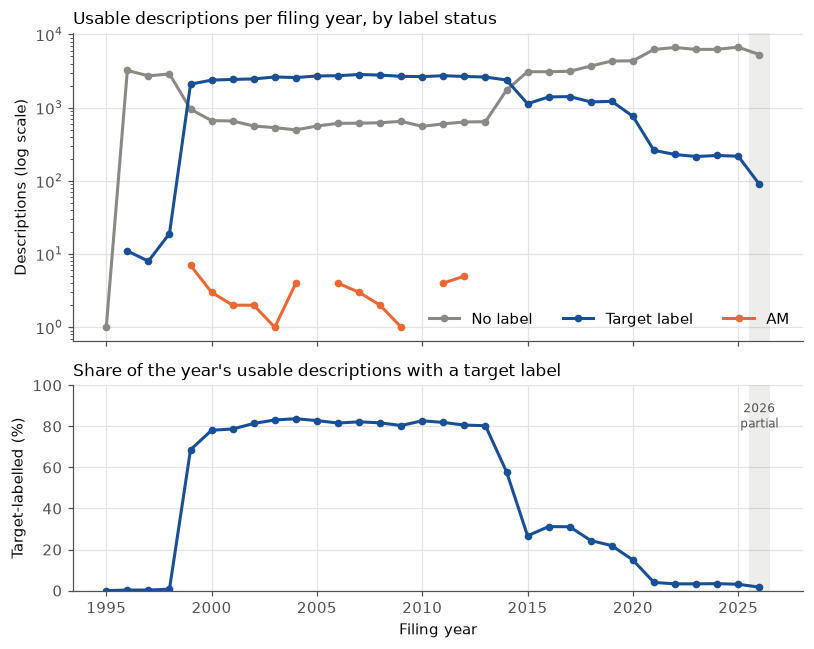

In [26]:
partial_year = snapshot_date.year
fig, (counts_ax, share_ax) = plt.subplots(
    2, 1, figsize=(7.5, 6), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
)
for column, label, colour in [
    ("unlabelled", "No label", GREY),
    ("target_labelled", "Target label", "#184f95"),
    ("am", "AM", "#eb6834"),
]:
    counts_ax.plot(
        yearly.index,
        yearly[column].where(yearly[column] > 0),
        marker="o",
        markersize=4,
        linewidth=2,
        color=colour,
        label=label,
    )
counts_ax.set_yscale("log")
counts_ax.set_ylabel("Descriptions (log scale)")
counts_ax.legend(loc="lower right", ncols=3)
counts_ax.set_title("Usable descriptions per filing year, by label status")

share_ax.plot(
    yearly.index,
    yearly["target_labelled_pct"],
    marker="o",
    markersize=4,
    linewidth=2,
    color="#184f95",
)
share_ax.set_ylim(0, 100)
share_ax.set_ylabel("Target-labelled (%)")
share_ax.set_xlabel("Filing year")
share_ax.set_title("Share of the year's usable descriptions with a target label")

for ax in (counts_ax, share_ax):
    ax.axvspan(partial_year - 0.5, partial_year + 0.5, color=GREY, alpha=0.15, linewidth=0)
share_ax.annotate(
    f"{partial_year}\npartial", (partial_year, 92), ha="center", va="top", color=MUTED, fontsize=8
)
fig.tight_layout()
save_figure(fig, "label_availability_over_time")
plt.show()

**Finding:** Target labels are almost absent in 1996–1998 (under 1% of descriptions), jump in 1999
and cover 78–84% of descriptions each year from 2000 to 2013. From 2014 coverage falls: 57.9% in
2014, 26.7% in 2015 and 14.9% in 2020, then 3.1–4.0% in 2021–2025 and 1.7% (90 of 5,401) in the
partial 2026. Description volume moves the other way: about 2,700–3,500 per year from 1996 to 2013, then from
4,120 in 2014 to 6,917 in 2025, almost all of the increase unlabelled. AM never exceeds seven records
a year; the log scale cannot show zero, so AM points appear only in years with at least one record.

The plot shows when labels are missing, not why. Recent labelled records are a small, possibly
selective subset of recent descriptions; Sections 8.3–8.4 compare them with the unlabelled ones.

### 8.2 Class composition across periods

**Question:** Does the class mix among labelled records change between the calendar periods used for
partitioning?

**Method:** Within each period from `config.yaml`, compute class shares among target-labelled
descriptions only. AM and unlabelled records are not in the denominators.

label,AFF,AGR,AGV,EQU,NOU,PI,REN,VIL,n,descriptions_in_period
period,,,,,,,,,,
≤2010,1.4,4.3,4.1,9.1,5.8,32.0,37.9,5.3,30989,47318
2011–2012,0.8,3.8,3.2,10.0,5.6,30.3,40.8,5.5,5398,6645
2013,0.8,3.8,3.0,8.0,6.1,38.9,33.4,6.0,2617,3260
2014–2026 (partial 2026),0.5,6.3,4.4,9.2,16.4,20.9,23.5,18.9,10742,71583


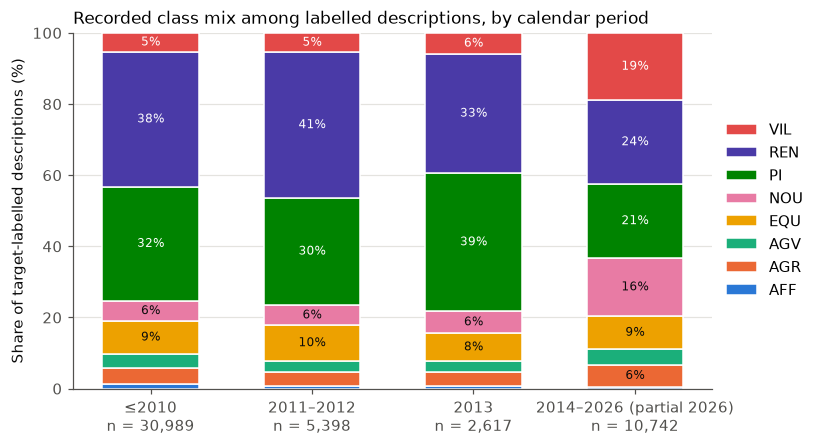

In [27]:
period_names = ["train_original", "validation", "test_historical", "test_recent"]
period_labels = ["≤2010", "2011–2012", "2013", f"2014–{partial_year} (partial {partial_year})"]

labelled_years = coverage.loc[has_text & target_label, "year"]
class_mix = pd.DataFrame(
    {
        "label": df.loc[has_text & target_label, "TYPE_OPERATION"],
        "period": pd.cut(
            labelled_years,
            bins=[0, *(splits[name]["to"] for name in period_names)],
            labels=period_labels,
        ),
    }
)
period_counts = class_mix["period"].value_counts().reindex(period_labels)
period_descriptions = (
    pd.cut(
        coverage.loc[has_text, "year"],
        bins=[0, *(splits[name]["to"] for name in period_names)],
        labels=period_labels,
    )
    .value_counts()
    .reindex(period_labels)
)
period_shares = pd.crosstab(class_mix["period"], class_mix["label"], normalize="index").reindex(
    columns=target_classes
)
display(
    (100 * period_shares)
    .round(1)
    .assign(n=period_counts, descriptions_in_period=period_descriptions)
)

LIGHT_CLASSES = {"AGR", "AGV", "EQU", "NOU"}  # dark ink keeps segment labels readable
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bottom = pd.Series(0.0, index=period_shares.index)
for label in target_classes:
    share = 100 * period_shares[label]
    bars = ax.bar(
        [f"{period}\nn = {period_counts[period]:,}" for period in period_shares.index],
        share,
        bottom=bottom,
        width=0.6,
        color=CLASS_COLOURS[label],
        edgecolor="white",
        linewidth=1,
        label=label,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.0f}%" if value >= 5 else "" for value in share],
        label_type="center",
        fontsize=8,
        color=INK if label in LIGHT_CLASSES else "white",
    )
    bottom += share
ax.set_ylim(0, 100)
ax.set_ylabel("Share of target-labelled descriptions (%)")
ax.grid(axis="x", visible=False)
ax.legend(
    handles=ax.get_legend_handles_labels()[0][::-1],
    labels=target_classes[::-1],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
ax.set_title("Recorded class mix among labelled descriptions, by calendar period")
save_figure(fig, "class_composition_by_period")
plt.show()

**Finding:** Through 2013 the mix is fairly stable: REN and PI together hold about 70% of labelled
records in each period. In 2014–2026 it shifts: VIL rises from about 5% to 19% and NOU from about 6%
to 16%, while REN falls from 38% to 23.5% and PI from 32% to 21%. AFF shrinks from 1.4% to 0.5%.

The figure describes recorded labels among labelled records only; in 2014–2026 the 10,742 labelled
descriptions are 15.0% of the period's 71,583 usable descriptions. It does not establish how construction
activity was distributed across all records, and it cannot separate a real change in permits from a
change in which dossiers still receive a label.

### 8.3 Coverage by origin and dossier type

**Question:** Within the recent years, do labelled and unlabelled descriptions come from the same
sources and dossier types?

**Method:** Compute label availability by origin and by dossier type within 2014–2020 and 2021–2026.
These two sub-periods separate the gradual decline from the years of very low coverage; they do not
change the partitions.

In [28]:
recent_coverage = coverage.loc[has_text & coverage["year"].between(2014, partial_year)].copy()
recent_coverage["period"] = pd.cut(
    recent_coverage["year"],
    bins=[2013, 2020, partial_year],
    labels=["2014–2020", f"2021–{partial_year}"],
)
for column in ["ORIGINE", "TYPE_DOSSIER"]:
    with pd.option_context("display.max_rows", None):
        display(label_availability(recent_coverage, ["period", column]).drop(columns="am"))

descriptions  target_labelled  unlabelled  \
period    ORIGINE                                              
2014–2020 AC-DEM             14                0          14   
          SAD             20546                1       20545   
          SIT             12408             9507        2901   
2021–2026 AC-DEM          20917              528       20389   
          SAD             16764                3       16761   
          SIT               934              703         231   

                   target_labelled_pct  
period    ORIGINE                       
2014–2020 AC-DEM                   0.0  
          SAD                      0.0  
          SIT                     76.6  
2021–2026 AC-DEM                   2.5  
          SAD                      0.0  
          SIT                     75.3

descriptions  target_labelled  unlabelled  \
period    TYPE_DOSSIER                                              
2014–2020 APA                  21099             1994       19105   
          APAT                    87                9          78   
          DD                    9747             7249        2498   
          DP                     367              253         114   
          M                     1654                3        1651   
          MPA                     14                0          14   
2021–2026 APA                  29269                2       29267   
          APAT                    37                0          37   
          DD                    7762             1205        6557   
          DP                     282               27         255   
          DR                       2                0           2   
          M                      829                0         829   
          MPA                    434                0         434   

                        target_labelled_pct  
period    TYPE_DOSSIER                       
2014–2020 APA                           9.5  
          APAT                         10.3  
          DD                           74.4  
          DP                           68.9  
          M                             0.2  
          MPA                           0.0  
2021–2026 APA                           0.0  
          APAT                          0.0  
          DD                           15.5  
          DP                            9.6  
          DR                            0.0  
          M                             0.0  
          MPA                           0.0

**Finding:** Availability depends strongly on origin. SIT records keep 75–77% coverage in both
sub-periods, while SAD has one target label in 2014–2020 and three in 2021–2026, and AC-DEM reaches
2.5% in the later period. By dossier type, DD holds 1,205 of the 1,234 target-labelled descriptions
in 2021–2026 (97.6%), while APA has 29,267 unlabelled descriptions and two labelled ones.

The recent labelled population therefore differs in composition from the unlabelled pool. Origin and
dossier type overlap, so these tables do not separate their effects or explain why labels are
missing.

### 8.4 Text characteristics and status

**Question:** Do recent labelled and unlabelled descriptions also differ in their text and recorded
status?

**Method:** Within each recent sub-period, compare row counts, distinct normalized texts, length and
the share at the 254-character boundary between labelled and unlabelled descriptions. Then compute
availability per recorded status, which is the status in this snapshot and not the status when a
label was or was not assigned.

In [29]:
recent_text = text_audit.merge(
    recent_coverage[["OBJECTID", "period", "target_labelled", "unlabelled"]],
    on="OBJECTID",
    validate="one_to_one",
)
recent_text = recent_text.loc[recent_text["target_labelled"] | recent_text["unlabelled"]]
recent_text_summary = (
    recent_text.assign(
        label_status=recent_text["target_labelled"].map(
            {True: "Target-labelled", False: "Unlabelled"}
        )
    )
    .groupby(["period", "label_status"], observed=True)
    .agg(
        records=("OBJECTID", "size"),
        unique_normalized_texts=("normalized_text", "nunique"),
        median_characters=("characters", "median"),
        p95_characters=("characters", lambda values: values.quantile(0.95)),
        at_254_pct=("characters", lambda values: 100 * values.eq(254).mean()),
    )
    .round(2)
)
display(recent_text_summary)

# A status absent in a period has no coverage to report: shown as "—", not 0%.
status_coverage = label_availability(recent_coverage, ["STATUT", "period"])[
    ["descriptions", "target_labelled_pct"]
].unstack("period")
status_coverage["descriptions"] = status_coverage["descriptions"].fillna(0).astype(int)
display(status_coverage.style.format(precision=1, na_rep="—"))

records  unique_normalized_texts  \
period    label_status                                        
2014–2020 Target-labelled     9508                     8487   
          Unlabelled         23460                    12215   
2021–2026 Target-labelled     1234                     1209   
          Unlabelled         37381                    20905   

                           median_characters  p95_characters  at_254_pct  
period    label_status                                                    
2014–2020 Target-labelled               77.0           191.0         0.8  
          Unlabelled                    45.0           125.0        0.13  
2021–2026 Target-labelled              126.0           225.7         3.0  
          Unlabelled                    59.0           194.0        1.81

**Finding:** Labelled descriptions are longer than unlabelled ones in both sub-periods: median 77
against 45 characters in 2014–2020 and 126 against 59 in 2021–2026. The share at 254 characters is
also higher among labelled records (0.80% against 0.13%, then 3.00% against 1.81%); these are
boundary counts, not confirmed truncations. Unlabelled groups have far fewer distinct normalized
texts than rows, indicating more standard wording.

By status, coverage of `TERMINE` falls from 29.3% in 2014–2020 to 0.7% in 2021–2026, so labels are
missing even for completed dossiers. Small groups need caution, and status may overlap with origin
and dossier type. Overall, recent labelled and unlabelled descriptions differ in time, source,
dossier type, status and text.

## 9. CamemBERTav2 tokenization

**Question:** How many CamemBERTav2 tokens do descriptions need, and does a sequence limit truncate
any?

**Method:** Load the tokenizer at the revision pinned in `config.yaml`, verify the loading path, and
count tokens for every distinct description with special tokens and without truncation.

At this revision `AutoTokenizer` builds a byte-level BPE backend in this environment, whereas the
published `tokenizer.json` defines WordPiece; the BPE path splits French words into single
characters and inflates lengths. The tokenizer is therefore built directly from the published file
with `PreTrainedTokenizerFast`. The next cell reproduces the mismatch and checks the result.

In [30]:
from huggingface_hub import hf_hub_download
from tokenizers import Tokenizer
from transformers import AutoTokenizer, PreTrainedTokenizerFast

model_config = config["models"]["primary"]
tokenizer_path = hf_hub_download(
    model_config["id"], "tokenizer.json", revision=model_config["revision"]
)
tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=tokenizer_path,
    cls_token="[CLS]",
    sep_token="[SEP]",
    bos_token="[CLS]",
    eos_token="[SEP]",
    unk_token="[UNK]",
    pad_token="[PAD]",
    mask_token="[MASK]",
    model_input_names=["input_ids", "attention_mask"],
)


def backend_type(loaded):
    return json.loads(loaded.backend_tokenizer.to_str())["model"]["type"]


automatic = AutoTokenizer.from_pretrained(model_config["id"], revision=model_config["revision"])
print("transformers", transformers.__version__, "| revision", model_config["revision"][:12])
print(
    "Published tokenizer.json:",
    json.loads(open(tokenizer_path, encoding="utf-8").read())["model"]["type"],
)
print("AutoTokenizer backend:   ", backend_type(automatic))
print("Direct load backend:     ", backend_type(tokenizer))
print(
    tokenizer.convert_ids_to_tokens(
        tokenizer("rénovation d'un appartement au 2ème étage")["input_ids"]
    )
)
assert backend_type(tokenizer) == "WordPiece"

transformers 5.17.0 | revision 54cc91d6ac45
Published tokenizer.json: WordPiece
AutoTokenizer backend:    BPE
Direct load backend:      WordPiece
['[CLS]', 'rénovation', "d'", 'un', 'appartement', 'au', '2', '##ème', 'étage', '[SEP]']


In [31]:
unique_descriptions = text_audit["DESCRIPTION"].drop_duplicates().tolist()
input_ids = tokenizer(unique_descriptions, add_special_tokens=True, truncation=False)["input_ids"]

reference_ids = [
    encoding.ids
    for encoding in Tokenizer.from_file(tokenizer_path).encode_batch(unique_descriptions)
]
assert input_ids == reference_ids, "The wrapper changed the published tokenization."

token_lengths = text_audit["DESCRIPTION"].map(
    dict(zip(unique_descriptions, map(len, input_ids), strict=True))
)
display(token_lengths.describe(percentiles=percentiles).round(1).to_frame(name="tokens"))

pd.DataFrame(
    {
        "records_exceeding": [(token_lengths > limit).sum() for limit in (32, 64, 128)],
        "percent_exceeding": [
            round(100 * (token_lengths > limit).mean(), 2) for limit in (32, 64, 128)
        ],
    },
    index=pd.Index([32, 64, 128], name="sequence_limit"),
)

,tokens
count,128806.0
mean,14.5
std,9.4
min,3.0
50%,12.0
90%,27.0
95%,35.0
99%,51.0
max,76.0


,records_exceeding,percent_exceeding
sequence_limit,,
32,7841,6.09
64,84,0.07
128,0,0.00


**Finding:** The directly loaded tokenizer reproduces the published token IDs for all 81,214 distinct
descriptions, and splits French text into words and subwords. Descriptions need a median of 12 tokens
and at most 76, including `[CLS]` and `[SEP]`. A 64-token limit would truncate 84 records; 128
truncates none in this snapshot. The 128 limit avoids additional tokenizer truncation but cannot
restore text already cut off at the source.

## 10. Exploratory review

**Question:** Do descriptions contain enough information to assign the eight classes, and how often
does a text-only assessment match the recorded label?

**Method:** Draw one record per target class and calendar period, plus four distinct unlabelled
descriptions from each recent sub-period, with a fixed seed. Each description was assessed before
its recorded label was revealed: a category where the text supports one, otherwise *ambiguous* or
*insufficient information*, with flags for multiple operations.

The assessments were AI-assisted and are not independent expert annotation. The sample is small and
deliberately selected, so it is exploratory. The assessments are stored in
`data/annotations/exploratory_review.csv`, bound to `OBJECTID` together with the exact description
reviewed.

In [32]:
review_candidates = text_audit.merge(
    coverage[["OBJECTID", "year"]], on="OBJECTID", how="left", validate="one_to_one"
)
review_candidates["review_period"] = pd.cut(
    review_candidates["year"],
    bins=[0, 2010, 2012, 2013, 2020, 2026],
    labels=["≤2010", "2011–2012", "2013", "2014–2020", "2021–2026"],
)

review_samples = [
    group.sample(n=1, random_state=42)
    for _, group in review_candidates.loc[
        review_candidates["TYPE_OPERATION"].isin(target_classes)
    ].groupby(["label_group", "review_period"], observed=True)
]
unlabelled_candidates = review_candidates.loc[
    review_candidates["label_group"].eq("Unlabelled")
    & review_candidates["year"].between(2014, 2026)
]
for _, group in unlabelled_candidates.groupby("review_period", observed=True):
    distinct = group.drop_duplicates("normalized_text")
    review_samples.append(distinct.sample(n=min(4, len(distinct)), random_state=42))

review_sample = pd.concat(review_samples).sample(frac=1, random_state=42).reset_index(drop=True)

manual_review = pd.read_csv(
    ANNOTATIONS_DIR / "exploratory_review.csv",
    dtype={"OBJECTID": "string"},
)
assert len(manual_review) == len(review_sample) == 48
assert manual_review["OBJECTID"].is_unique
assert set(manual_review["OBJECTID"]) == set(review_sample["OBJECTID"]), "The sample changed."
assert (
    manual_review["review_status"].isin(["assigned", "ambiguous", "insufficient_information"]).all()
)
assert (
    manual_review["assigned_category"]
    .notna()
    .eq(manual_review["review_status"].eq("assigned"))
    .all()
)
current_text = df.set_index("OBJECTID").loc[manual_review["OBJECTID"], "DESCRIPTION"]
assert (current_text.to_numpy() == manual_review["description"].to_numpy()).all(), (
    "A reviewed description changed."
)
print("48 assessments match the sampled OBJECTIDs and their descriptions.")

48 assessments match the sampled OBJECTIDs and their descriptions.


In [33]:
review_results = manual_review.merge(
    review_sample[["OBJECTID", "TYPE_OPERATION"]], on="OBJECTID", validate="one_to_one"
)
has_recorded_label = review_results["TYPE_OPERATION"].isin(target_classes)
assigned = review_results["review_status"].eq("assigned")
same_label = review_results["assigned_category"].eq(review_results["TYPE_OPERATION"])

review_results["comparison"] = "No recorded target label"
review_results.loc[has_recorded_label & ~assigned, "comparison"] = "Unresolved review"
review_results.loc[has_recorded_label & assigned & same_label, "comparison"] = "Agreement"
review_results.loc[has_recorded_label & assigned & ~same_label, "comparison"] = "Disagreement"

display(pd.crosstab(review_results["review_status"], review_results["comparison"], margins=True))
print("Assessments noting multiple operations:", review_results["multiple_operations"].sum())
with pd.option_context("display.max_colwidth", None):
    display(
        review_results.loc[
            review_results["comparison"].eq("Disagreement"),
            ["review_id", "description", "TYPE_OPERATION", "assigned_category", "notes"],
        ].sort_values("review_id")
    )

comparison,Agreement,Disagreement,No recorded target label,Unresolved review,All
review_status,,,,,
ambiguous,0,0,2,7,9
assigned,21,3,5,0,29
insufficient_information,0,0,1,9,10
All,21,3,8,16,48


Assessments noting multiple operations: 20


,review_id,description,TYPE_OPERATION,assigned_category,notes
9,10,installation d'un sanitaire public monobloc,PI,EQU,Installation of a public sanitation facility.
15,16,démolition des greniers avec réalisation de deux étages sur combles - panneaux solaires en toiture,AGV,AGR,Creation of two additional levels is the main stated work; also attic demolition and solar panels.
46,47,changement des tuiles de la toiture,PI,REN,Replacement of roof tiles.


**Finding:** Of the 48 assessments (40 target-labelled records, 8 unlabelled), 29 assign a category,
10 find insufficient information and 9 are ambiguous; 20 note multiple operations. Among the 24
records with both an assigned category and a recorded target label, 21 agree. The three
disagreements are a public toilet recorded as PI (assessed EQU), an attic extension recorded as AGV
(assessed AGR) and roof-tile replacement recorded as PI (assessed REN); either side may lack context.

This is conditional agreement in a deliberately selected sample, not measured human accuracy or
population-wide label quality. The review mainly shows recurring limits of the text: unspecified
building type or public/private context, multiple operations and supplementary requests that repeat
the original project. It does not show that the unlabelled pool fits the taxonomy.

## 11. Partitions and overlap exclusions

Three kinds of set appear below and should not be confused:

- **Original candidate partitions:** every usable description assigned by filing year and label status.
- **Retained partitions:** the candidates left after the overlap exclusions in Section 11.2.
- **Accepted datasets:** future training or annotation sets. The retained pool is only a candidate
  for annotation, not accepted training data.

### 11.1 Candidate partitions and their overlap

**Question:** How large are the candidate partitions, and how much do they share across the calendar
boundaries?

**Method:** Assign target-labelled descriptions to training (through 2010), validation (2011–2012),
historical test (2013) and recent test (2014–2026), and unlabelled recent descriptions to the
candidate pool. Count rows, base dossiers and texts per partition, then the base dossiers, exact
texts and normalized texts shared by each pair.

In [34]:
split_audit = text_audit.merge(
    df[["OBJECTID", "TYPE_DOSSIER", "NO_DOSSIER", "DATE_DEPOT"]],
    on="OBJECTID",
    validate="one_to_one",
)
split_audit["year"] = split_audit["DATE_DEPOT"].dt.year
split_audit["base_dossier"] = split_audit["TYPE_DOSSIER"] + " " + split_audit["NO_DOSSIER"]
split_audit["partition"] = pd.Series(pd.NA, index=split_audit.index, dtype="string")

partition_order = [*period_names, "pool_unlabelled"]
is_target = split_audit["TYPE_OPERATION"].isin(target_classes)
for partition in period_names:
    bounds = splits[partition]
    split_audit.loc[
        is_target & split_audit["year"].between(bounds.get("from", 0), bounds["to"]), "partition"
    ] = partition

pool_bounds = splits["pool_unlabelled"]
in_pool_period = split_audit["year"].between(pool_bounds["from"], pool_bounds["to"])
split_audit.loc[split_audit["label_group"].eq("Unlabelled") & in_pool_period, "partition"] = (
    "pool_unlabelled"
)

candidate_splits = split_audit.loc[split_audit["partition"].notna()].copy()
candidate_splits["manually_reviewed"] = candidate_splits["OBJECTID"].isin(manual_review["OBJECTID"])


def partition_profile(frame):
    return (
        frame.groupby("partition")
        .agg(
            rows=("OBJECTID", "size"),
            base_dossiers=("base_dossier", "nunique"),
            exact_texts=("DESCRIPTION", "nunique"),
            normalized_texts=("normalized_text", "nunique"),
            reviewed_rows=("manually_reviewed", "sum"),
        )
        .reindex(partition_order)
    )


display(partition_profile(candidate_splits))

overlap = pd.DataFrame(
    [
        {
            "partition_1": left,
            "partition_2": right,
            **{
                f"shared_{name}": len(
                    set(candidate_splits.loc[candidate_splits["partition"].eq(left), column])
                    & set(candidate_splits.loc[candidate_splits["partition"].eq(right), column])
                )
                for name, column in [
                    ("base_dossiers", "base_dossier"),
                    ("exact_texts", "DESCRIPTION"),
                    ("normalized_texts", "normalized_text"),
                ]
            },
        }
        for left, right in combinations(partition_order, 2)
    ]
)
overlap

,rows,base_dossiers,exact_texts,normalized_texts,reviewed_rows
partition,,,,,
train_original,30989,30934,20722,19800,8
validation,5398,5382,4010,3867,8
test_historical,2617,2610,2065,2041,8
test_recent,10742,9685,9858,9679,16
pool_unlabelled,60841,57794,34263,32084,8


,partition_1,partition_2,shared_base_dossiers,shared_exact_texts,shared_normalized_texts
0,train_original,validation,41,593,629
1,train_original,test_historical,21,310,342
2,train_original,test_recent,116,393,448
3,train_original,pool_unlabelled,79,932,1096
4,validation,test_historical,51,216,232
5,validation,test_recent,228,220,244
6,validation,pool_unlabelled,113,441,525
7,test_historical,test_recent,217,172,187
8,test_historical,pool_unlabelled,105,289,318
9,test_recent,pool_unlabelled,1482,754,925


**Finding:** The candidate partitions hold 30,989 training, 5,398 validation, 2,617 historical-test,
10,742 recent-test and 60,841 pool rows. Every pair shares base dossiers and texts. The largest
overlap is between the recent test and the pool: 1,482 base dossiers and 925 normalized texts. The
calendar boundaries alone therefore leave related applications and identical texts on both sides of
an evaluation boundary.

### 11.2 Exclusion policy

**Question:** Which candidate records must be excluded so that evaluation records share no dossier,
text or review exposure with other partitions?

**Method:** Give every candidate row one exclusion reason, applied in this order:

1. **Dossier overlap** (all partitions): the base dossier occurs in more than one original candidate
   partition.
2. **Text overlap** (validation and both tests): the normalized text occurs in another original
   candidate partition.
3. **Review exposure** (validation and both tests): the record shares a base dossier or normalized
   text with the exploratory review sample.

All comparisons use the original candidate partitions, including the annotation pool, so a record's
outcome does not depend on what other rules removed first.

In [35]:
evaluation_partitions = ["validation", "test_historical", "test_recent"]
reviewed_records = candidate_splits.loc[candidate_splits["manually_reviewed"]]
split_decisions = candidate_splits.copy()
split_decisions["exclusion_reason"] = "Retained"

partitions_per_dossier = candidate_splits.groupby("base_dossier")["partition"].nunique()
crossing_dossiers = partitions_per_dossier.index[partitions_per_dossier > 1]
split_decisions.loc[split_decisions["base_dossier"].isin(crossing_dossiers), "exclusion_reason"] = (
    "Dossier overlap"
)

still_retained = split_decisions["exclusion_reason"].eq("Retained")
for partition in evaluation_partitions:
    other_texts = candidate_splits.loc[
        candidate_splits["partition"].ne(partition), "normalized_text"
    ]
    text_overlap = split_decisions["partition"].eq(partition) & split_decisions[
        "normalized_text"
    ].isin(other_texts)
    split_decisions.loc[still_retained & text_overlap, "exclusion_reason"] = "Text overlap"

review_exposure = split_decisions["base_dossier"].isin(
    reviewed_records["base_dossier"]
) | split_decisions["normalized_text"].isin(reviewed_records["normalized_text"])
split_decisions.loc[
    split_decisions["partition"].isin(evaluation_partitions)
    & split_decisions["exclusion_reason"].eq("Retained")
    & review_exposure,
    "exclusion_reason",
] = "Review exposure"

reason_order = ["Retained", "Dossier overlap", "Text overlap", "Review exposure"]
exclusion_summary = pd.crosstab(
    split_decisions["partition"], split_decisions["exclusion_reason"]
).reindex(index=partition_order, columns=reason_order, fill_value=0)
exclusion_summary["retained_pct"] = (
    100 * exclusion_summary["Retained"] / exclusion_summary[reason_order].sum(axis=1)
).round(1)
display(exclusion_summary)

retained_splits = split_decisions.loc[split_decisions["exclusion_reason"].eq("Retained")].copy()
assert (retained_splits.groupby("base_dossier")["partition"].nunique() == 1).all(), (
    "A dossier spans partitions."
)
for partition in evaluation_partitions:
    rows = retained_splits.loc[retained_splits["partition"].eq(partition)]
    others = retained_splits.loc[retained_splits["partition"].ne(partition)]
    assert set(rows["normalized_text"]).isdisjoint(others["normalized_text"]), (
        f"Text overlap in {partition}."
    )
    assert not rows["base_dossier"].isin(reviewed_records["base_dossier"]).any(), (
        f"Reviewed dossier in {partition}."
    )
    assert not rows["normalized_text"].isin(reviewed_records["normalized_text"]).any(), (
        f"Reviewed text in {partition}."
    )
print("Dossier, normalized-text and review-exposure separation checks passed.")

exclusion_reason,Retained,Dossier overlap,Text overlap,Review exposure,retained_pct
partition,,,,,
train_original,30782,207,0,0,99.3
validation,2794,347,2249,8,51.8
test_historical,1320,313,978,6,50.4
test_recent,6671,2337,1723,11,62.1
pool_unlabelled,58482,2359,0,0,96.1


Dossier, normalized-text and review-exposure separation checks passed.


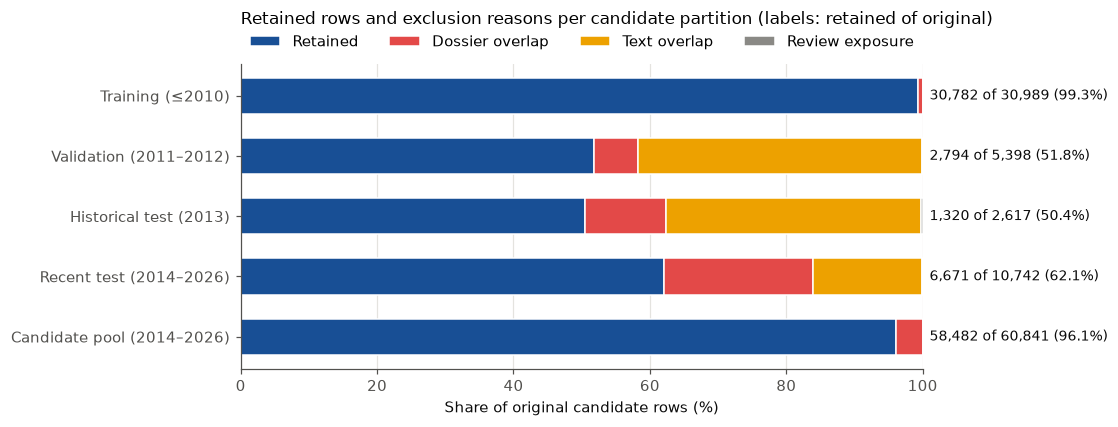

In [36]:
reason_colours = {
    "Retained": "#184f95",
    "Dossier overlap": "#e34948",
    "Text overlap": "#eda100",
    "Review exposure": GREY,
}
partition_labels = {
    "train_original": "Training (≤2010)",
    "validation": "Validation (2011–2012)",
    "test_historical": "Historical test (2013)",
    "test_recent": f"Recent test (2014–{partial_year})",
    "pool_unlabelled": f"Candidate pool (2014–{partial_year})",
}
totals = exclusion_summary[reason_order].sum(axis=1)
shares = 100 * exclusion_summary[reason_order].div(totals, axis=0)
plotted = shares.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 3.6))
left = pd.Series(0.0, index=plotted.index)
for reason in reason_order:
    ax.barh(
        [partition_labels[name] for name in plotted.index],
        plotted[reason],
        left=left,
        height=0.6,
        color=reason_colours[reason],
        edgecolor="white",
        linewidth=1,
        label=reason,
    )
    left += plotted[reason]
for position, name in enumerate(plotted.index):
    ax.text(
        101,
        position,
        f"{exclusion_summary.loc[name, 'Retained']:,} of {totals[name]:,} "
        f"({exclusion_summary.loc[name, 'retained_pct']:.1f}%)",
        va="center",
        fontsize=9,
        color=INK,
    )
ax.set_xlim(0, 100)
ax.set_xlabel("Share of original candidate rows (%)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=4)
ax.set_title(
    "Retained rows and exclusion reasons per candidate partition (labels: retained of original)",
    pad=26,
)
save_figure(fig, "partition_exclusions")
plt.show()

**Finding:** Training keeps 30,782 of 30,989 rows (99.3%) and the pool 58,482 of 60,841 (96.1%),
because only dossier overlap applies to them. The evaluation partitions lose far more: validation
keeps 2,794 of 5,398 (51.8%), the historical test 1,320 of 2,617 (50.4%) and the recent test 6,671
of 10,742 (62.1%). Text overlap is the largest reason in validation and the historical test, and
dossier overlap in the recent test. Review exposure removes 25 rows in total, too few to be visible
in the figure. The checks above confirm
that no retained base dossier spans partitions and that evaluation partitions share no normalized
text or review exposure.

### 11.3 Retained class support and composition

**Question:** Do the exclusions change the class and year composition of the evaluation partitions,
not just their size?

**Method:** Compare class support before and after exclusions for each labelled partition, and the
recent test's retention by filing year.

In [37]:
def class_support(frame):
    return pd.crosstab(frame["partition"], frame["label_group"]).reindex(
        index=period_names, columns=target_classes, fill_value=0
    )


retained_support = class_support(retained_splits)
display(retained_support.assign(total=retained_support.sum(axis=1)))
display(
    (100 * retained_support / class_support(candidate_splits))
    .round(1)
    .rename_axis("retained % of candidate")
)

recent_years = (
    pd.DataFrame(
        {
            "candidate": candidate_splits.loc[candidate_splits["partition"].eq("test_recent")]
            .groupby("year")
            .size(),
            "retained": retained_splits.loc[retained_splits["partition"].eq("test_recent")]
            .groupby("year")
            .size(),
        }
    )
    .fillna(0)
    .astype(int)
)
recent_years["retained_pct"] = (100 * recent_years["retained"] / recent_years["candidate"]).round(1)
recent_years.T

label_group,AFF,AGR,AGV,EQU,NOU,PI,REN,VIL,total
partition,,,,,,,,,
train_original,437,1310,1258,2808,1709,9917,11712,1631,30782
validation,30,122,113,350,136,670,1155,218,2794
test_historical,12,45,50,133,58,525,411,86,1320
test_recent,31,380,278,760,921,1471,1449,1381,6671


label_group,AFF,AGR,AGV,EQU,NOU,PI,REN,VIL
retained % of candidate,,,,,,,,
train_original,99.5,97.4,99.1,99.8,95.4,99.9,99.6,98.7
validation,68.2,58.9,66.1,64.9,44.9,41.0,52.4,73.6
test_historical,57.1,45.0,63.3,63.6,36.5,51.6,47.0,55.1
test_recent,60.8,56.5,58.8,77.0,52.4,65.6,57.4,67.9


year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
candidate,2386.0,1130.0,1400.0,1416.0,1197.0,1218.0,761.0,261.0,229.0,215.0,222.0,217.0,90.0
retained,1213.0,656.0,875.0,951.0,772.0,780.0,516.0,159.0,146.0,147.0,174.0,196.0,86.0
retained_pct,50.8,58.1,62.5,67.2,64.5,64.0,67.8,60.9,63.8,68.4,78.4,90.3,95.6


**Finding:** All eight classes remain in every labelled partition, but AFF support is small: 30
validation, 12 historical-test and 31 recent-test records. One AFF error in the historical test moves
its AFF recall by more than eight points, so per-class AFF results need wide uncertainty.

Retention differs by class and year. In the recent test NOU keeps 52.4% of its rows and EQU 77.0%.
Recent-test retention ranges from 50.8% in 2014 to 95.6% in partial 2026; among complete years, the
maximum is 90.3% in 2025. The exclusions therefore produce a more
restrictive evaluation population with a different composition. They do not prove complete semantic
independence, since near-duplicates beyond the normalized key remain, and they do not make the
labelled tests representative of the unlabelled pool.

### 11.4 Record ledger

**Question:** Is every source record accounted for exactly once?

**Method:** Assign each of the source rows one outcome: no description, AM, outside the candidate
periods, an overlap exclusion, or retained in a partition.

In [38]:
record_ledger = df[["OBJECTID"]].copy()
record_ledger["outcome"] = "Outside candidate periods"
record_ledger.loc[no_text, "outcome"] = "No description"
record_ledger.loc[has_text & am_label, "outcome"] = "AM (outside eight-class scope)"

decisions = split_decisions.set_index("OBJECTID")
candidate_outcome = decisions["exclusion_reason"].where(
    decisions["exclusion_reason"].ne("Retained"), "Retained: " + decisions["partition"]
)
record_ledger["outcome"] = (
    record_ledger["OBJECTID"].map(candidate_outcome).fillna(record_ledger["outcome"])
)

assert record_ledger["OBJECTID"].is_unique and len(record_ledger) == len(df)
assert set(
    record_ledger.loc[record_ledger["outcome"].str.startswith("Retained:"), "OBJECTID"]
) == set(retained_splits["OBJECTID"])

outside = record_ledger["outcome"].eq("Outside candidate periods")
print(
    "Outside candidate periods, by label status:",
    text_audit.set_index("OBJECTID")
    .loc[record_ledger.loc[outside, "OBJECTID"], "label_group"]
    .eq("Unlabelled")
    .map({True: "unlabelled ≤2013", False: "labelled, no year"})
    .value_counts()
    .to_dict(),
)
record_ledger["outcome"].value_counts().to_frame(name="records").assign(
    percent=lambda table: (100 * table["records"] / len(df)).round(2)
)

Outside candidate periods, by label status: {'unlabelled ≤2013': 18181}


,records,percent
outcome,,
No description,68418,34.69
Retained: pool_unlabelled,58482,29.65
Retained: train_original,30782,15.61
Outside candidate periods,18181,9.22
Retained: test_recent,6671,3.38
Dossier overlap,5563,2.82
Text overlap,4950,2.51
Retained: validation,2794,1.42
Retained: test_historical,1320,0.67


**Finding:** The ledger accounts for all 197,224 source records once. 100,049 are retained: 41,567
target-labelled rows across training, validation and the two tests, plus 58,482 pool candidates.
The other 97,175 are excluded for a stated reason: 68,418 have no description, 38 are AM, 18,181 are
unlabelled descriptions filed before 2014 and so outside every candidate period, and 10,538 fall to
the overlap policy. Retained partitions can still contain repeated texts and several applications
from one dossier; no within-partition deduplication is applied.

## 12. Preparation decisions and limitations

**Decisions supported by this audit**

- Treat each field's observed placeholder (`--`, `-`, `non renseigné`, the `OPERATION` import
  default) and true nulls as missing.
- The population is the 128,806 records with a description. Labels count only by explicit membership
  in the eight target classes; AM stays a valid category outside the scope, and missing labels are not
  a class.
- Use the loader's recovered `DATE_DEPOT`, including the three timestamp-formatted dates.
- Keep `OBJECTID` as the record key and group related applications by base dossier
  `(TYPE_DOSSIER, NO_DOSSIER)`; leave the `DD 16944/1` number mismatch flagged, uncorrected.
- Feed the original descriptions to the model; use normalized text only for grouping and overlap.
- Keep short, repeated, ambiguous, boundary-length and label-conflicting descriptions; apply no
  automatic relabelling or label transfer.
- Use 128 tokens as the CamemBERTav2 candidate limit for the training pilot.
- Use the retained partitions from Section 11: 30,782 training, 2,794 validation, 1,320
  historical-test and 6,671 recent-test rows, and 58,482 pool candidates.

**Remaining uncertainties**

- Source labels are reference annotations, not ground truth: 19.4% of labelled rows share a
  normalized text with a different label.
- AFF has 12–31 evaluation records per partition, so its per-class results are fragile.
- Recent labelled records differ from the unlabelled pool in origin, dossier type, status and text,
  so test scores cannot be assumed to represent performance on the unlabelled pool, and the pool has not been shown to fit the taxonomy.
- Some descriptions are ambiguous, describe several operations or are cut at 254 characters.
- Near-duplicates beyond the normalized key remain across partitions.
- The exploratory review is small, AI-assisted and non-independent.
- The meanings of `APL`, the origin codes and several statuses are undocumented.